# **ITC Challeng**

In [ ]:
# Install necessary libraries
!pip install torch torchvision opencv-python

In [9]:
# ==============================
# 1. Standard Libraries
# ==============================
import os
import glob

# ==============================
# 2. Data Manipulation
# ==============================
import numpy as np
import pandas as pd

# ==============================
# 3. Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 4. Computer Vision
# ==============================
import cv2

# ==============================
# 5. Machine Learning (Scikit-Learn)
# ==============================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# ==============================
# 6. TensorFlow / Keras
# ==============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ==============================
# 7. PyTorch
# ==============================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# ==============================
# 8. Progress & Utilities
# ==============================
from tqdm import tqdm

# ==============================
# 9. Pretrained Models Library
# ==============================
import timm

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
train_dir = "/content/drive/MyDrive/Colab Notebooks/ITC Challange/cancer-image-classification-itc-challenge/train"
test_dir = "/content/drive/MyDrive/Colab Notebooks/ITC Challange/cancer-image-classification-itc-challenge/test"
labels_path = "/content/drive/MyDrive/Colab Notebooks/ITC Challange/cancer-image-classification-itc-challenge/train_labels.csv"

In [15]:
df = pd.read_csv(labels_path)

df["image_id"] = df["image_id"] + ".jpg"
df.rename(columns={"image_id":"filename"}, inplace=True)

print(df.head())

           filename  label
0  b0adceefee0c.jpg      1
1  7d025f9dfab8.jpg      1
2  5dc8ffe4cae1.jpg      1
3  c447bf046fc0.jpg      0
4  a93779dab573.jpg      0


In [5]:
print("DataFrame Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Labels:")
print(df['label'].unique())
print("\nLabel Value Counts:")
print(df['label'].value_counts())

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  7000 non-null   object
 1   label     7000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 109.5+ KB

Missing Values:
filename    0
label       0
dtype: int64

Number of Duplicate Rows:
0

Unique Labels:
[1 0]

Label Value Counts:
label
0    4445
1    2555
Name: count, dtype: int64


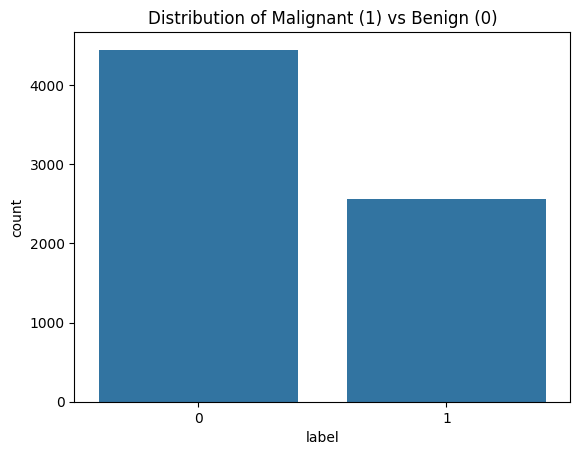

In [6]:
sns.countplot(x='label', data=df)
plt.title('Distribution of Malignant (1) vs Benign (0)')
plt.show()

In [7]:
print("Train images:", len(os.listdir(train_dir)))
print("Test images:", len(os.listdir(test_dir)))

Train images: 7000
Test images: 3000


In [8]:
from tqdm.notebook import tqdm
from PIL import Image

sizes = []

for img_id in tqdm(df['filename'].sample(200)):
    img_path = os.path.join(train_dir, img_id)
    img = Image.open(img_path)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Unique sizes:", np.unique(sizes, axis=0))

  0%|          | 0/200 [00:00<?, ?it/s]

Unique sizes: [[96 96]]


Benign Samples


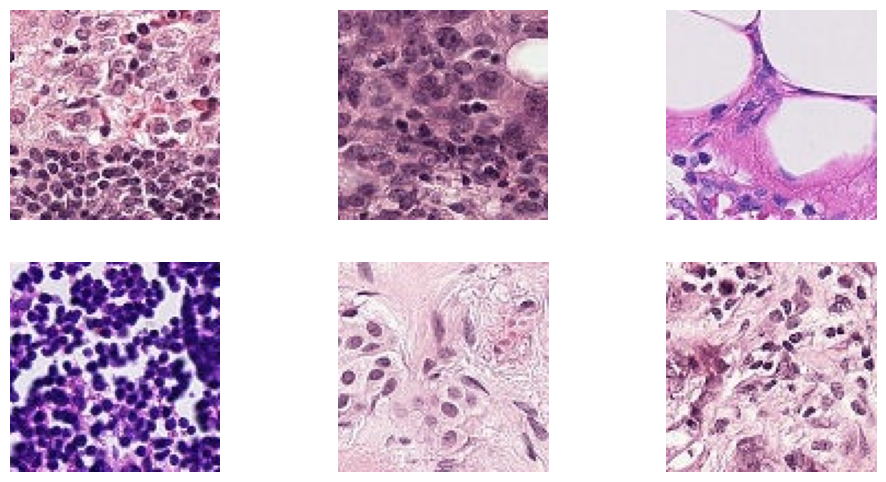

Malignant Samples


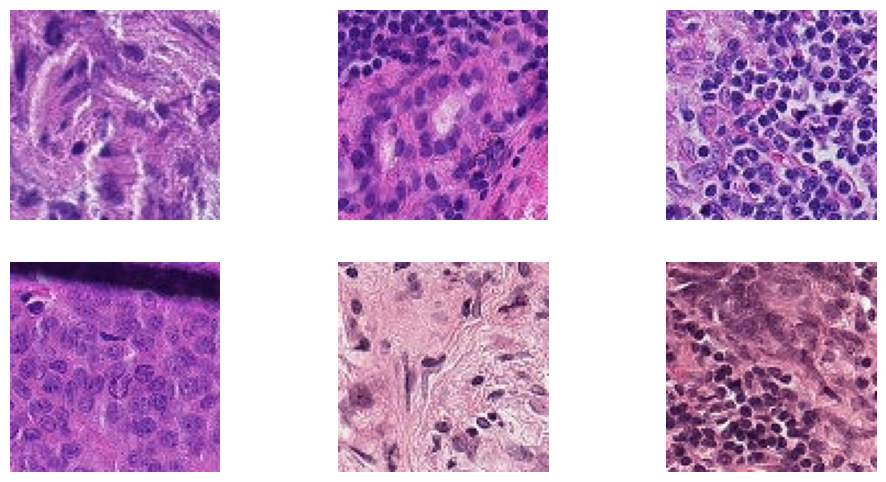

In [16]:
def show_images(label, n=6):
    imgs = df[df['label']==label]['filename'].sample(n)

    plt.figure(figsize=(12,6))

    for i,img_id in enumerate(imgs):

        img = Image.open(f"{train_dir}/{img_id}")

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.show()

print("Benign Samples")
show_images(0)

print("Malignant Samples")
show_images(1)

# **Train**

In [17]:
IMG_SIZE = 128
BATCH_SIZE = 64
EPOCHS = 10
LR = 1e-4

**Fold**

In [18]:
train_image_paths = {os.path.basename(x): x for x in glob.glob(os.path.join(train_dir, "*.jpg"))}
df["img_path"] = df["filename"].apply(lambda x: train_image_paths.get(x))

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
df["fold"] = -1
for fold, (train_idx, val_idx) in enumerate(skf.split(df, df["label"])):
    df.loc[val_idx, "fold"] = fold

# **Data Augementation**

In [19]:
train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(45),
    T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    T.RandomPerspective(distortion_scale=0.2, p=0.5),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


**DataSet**

In [20]:
class CancerDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.df = df
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["img_path"] if not self.is_test else self.df[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image)

        if self.is_test:
            return image

        label = self.df.iloc[idx]["label"]
        return image, torch.tensor(label, dtype=torch.float32)


**model**

In [21]:
def get_model():
    model = timm.create_model('convnext_tiny', pretrained=True, num_classes=1)
    return model

**Train**

In [22]:
def run_fold(fold):
    print(f"\n--- Training Fold: {fold} ---")
    train_df = df[df.fold != fold].reset_index(drop=True)
    valid_df = df[df.fold == fold].reset_index(drop=True)

    train_loader = DataLoader(CancerDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(CancerDataset(valid_df, val_transform), batch_size=BATCH_SIZE, shuffle=False)

    model = get_model().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCEWithLogitsLoss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_auc = 0
    train_losses_history = []
    valid_losses_history = []
    valid_aucs_history = []

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for imgs, labels in tqdm(train_loader, desc=f"Fold {fold} Ep {epoch+1}"):
            imgs, labels = imgs.to(device), labels.to(device).view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(imgs), labels)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item() * imgs.size(0)

        avg_train_loss = total_train_loss / len(train_loader.dataset)
        train_losses_history.append(avg_train_loss)

        # Validation
        model.eval()
        preds, targets = [], []
        total_valid_loss = 0
        with torch.no_grad():
            for imgs, labels in valid_loader:
                outputs = model(imgs.to(device))
                loss = criterion(outputs, labels.to(device).view(-1, 1))
                total_valid_loss += loss.item() * imgs.size(0)

                preds.extend(torch.sigmoid(outputs).cpu().numpy())
                targets.extend(labels.numpy())

        avg_valid_loss = total_valid_loss / len(valid_loader.dataset)
        valid_losses_history.append(avg_valid_loss)

        auc = roc_auc_score(targets, preds)
        valid_aucs_history.append(auc)

        print(f"Fold {fold} Epoch {epoch+1} - Train Loss: {avg_train_loss:.4f}, Valid Loss: {avg_valid_loss:.4f}, Valid AUC: {auc:.4f}")
        scheduler.step(auc)

        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), f"best_model_fold{fold}.pth")

    return {
        'best_auc': best_auc,
        'train_losses': train_losses_history,
        'valid_losses': valid_losses_history,
        'valid_aucs': valid_aucs_history
    }

In [ ]:
all_fold_results = {}
for fold in range(5):
    fold_metrics = run_fold(fold)
    all_fold_results[f'fold_{fold}'] = fold_metrics

In [ ]:
plt.figure(figsize=(14,6))

# -------- Plot Loss --------
plt.subplot(1,2,1)

for fold_name, results in all_fold_results.items():
    train_losses = results['train_losses']
    valid_losses = results['valid_losses']
    epochs_range = range(1, len(train_losses)+1)

    plt.plot(epochs_range, valid_losses, label=f'{fold_name} Validation Loss')

plt.title("Validation Loss for All Folds")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# -------- Plot AUC --------
plt.subplot(1,2,2)

for fold_name, results in all_fold_results.items():
    valid_aucs = results['valid_aucs']
    epochs_range = range(1, len(valid_aucs)+1)

    plt.plot(epochs_range, valid_aucs, label=f'{fold_name} AUC')

plt.title("Validation AUC for All Folds")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


**Predict**

In [ ]:
print("\n--- Starting Ensemble Inference ---")
test_images = [os.path.join(test_dir, f) for f in os.listdir(test_dir)]
test_dataset = CancerDataset(test_images, val_transform, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

final_preds = np.zeros(len(test_images))

for fold in range(5):
    print(f"Predicting with Fold {fold}...")
    model = get_model().to(device)
    model.load_state_dict(torch.load(f"best_model_fold{fold}.pth"))
    model.eval()

    fold_preds = []
    with torch.no_grad():
        for imgs in tqdm(test_loader):
            outputs = model(imgs.to(device))
            fold_preds.extend(torch.sigmoid(outputs).cpu().numpy().flatten())

    final_preds += np.array(fold_preds) / 5

**Save**

In [ ]:
submission = pd.DataFrame({
    "image_id": [os.path.basename(f).split('.')[0] for f in test_images],
    "label": final_preds
})
drive_path = "/content/drive/MyDrive/Colab Notebooks/ITC Challange/submission_final.csv"
submission.to_csv(drive_path, index=False)
print(f"done {drive_path}")